In [2]:

import numpy as np
import cv2
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# Chemin
INPUT_DIR = Path(r"C:\Users\hp\OneDrive\Bureau\PRIM\Personal Code\Data\Raw_Data (ILM_OPL)")


start_id = 10001
end_id = 10300

# Tailles et réglages
patch_size = 200
target_size = 256
median_kernel = 3

# Paramètres Gabor pour petits vaisseaux
thetas = np.linspace(0, np.pi, 12, endpoint=False)
gabor_lambd = 3.5
gabor_sigma = 1.75
gabor_gamma = 0.5


In [3]:
# Découpe d'une image 400x400 en 4 patches 200x200
def split_into_4_patches_cv2(img: np.ndarray, patch=200):
    h, w = img.shape
    if (h, w) != (400, 400):
        raise ValueError(f"Taille attendue 400x400, reçu {img.shape}")
    patches = [
        img[0:patch, 0:patch],
        img[0:patch, w - patch:w],
        img[h - patch:h, 0:patch],
        img[h - patch:h, w - patch:w],
    ]
    return patches

# Padding centré vers target x target avec pixels noirs
def pad_to_square_cv2(arr: np.ndarray, target=256):
    h, w = arr.shape
    if h > target or w > target:
        raise ValueError(f"Patch plus grand que la taille cible: {h}x{w} > {target}")
    dh = target - h
    dw = target - w
    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left
    out = cv2.copyMakeBorder(arr, top, bottom, left, right, borderType=cv2.BORDER_CONSTANT, value=0)
    return out

#filtres de Gabor pour rehausser les petits vaisseaux
def gabor_vessel_enhancement(img_uint8, thetas, lambd=4.0, sigma=2.0, gamma=0.5):
    img = img_uint8.astype(np.float32)
    responses = []
    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(9, 9),
            sigma=sigma,
            theta=theta,
            lambd=lambd,
            gamma=gamma,
            psi=0,
            ktype=cv2.CV_32F
        )
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        responses.append(filtered)
    vesselness = np.max(responses, axis=0)
    vesselness = vesselness - np.min(vesselness)
    vmax = np.max(vesselness)
    if vmax > 0:
        vesselness = vesselness / vmax * 255.0
    return vesselness.astype(np.uint8)


In [4]:
# Chargement des images brutes et découpe en patches 200x200
raw_patches_200 = []
renamed_ids = []

next_id = 1
for img_id in tqdm(range(start_id, end_id + 1), desc="Découpage en patches 200x200", ncols=80):
    img_path = INPUT_DIR / f"{img_id}.bmp"
    if not img_path.exists():
        raise FileNotFoundError(f"Introuvable: {img_path}")
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Lecture impossible: {img_path}")
    patches = split_into_4_patches_cv2(img, patch=patch_size)
    for p in patches:
        raw_patches_200.append(p.astype(np.uint8))
        renamed_ids.append(next_id)
        next_id += 1

raw_patches_200 = np.stack(raw_patches_200, axis=0)
renamed_ids = np.array(renamed_ids, dtype=np.int32)
print("Forme raw_patches_200:", raw_patches_200.shape)
print("Renommage 1..1200, premiers/derniers:", renamed_ids[:4], "...", renamed_ids[-4:])


Découpage en patches 200x200: 100%|███████████| 300/300 [00:03<00:00, 89.54it/s]

Forme raw_patches_200: (1200, 200, 200)
Renommage 1..1200, premiers/derniers: [1 2 3 4] ... [1197 1198 1199 1200]


In [5]:
# Application du filtre médian 3x3 sur les patches 200x200
print(f"Nombre total de patches: {len(raw_patches_200)}")
if raw_patches_200.dtype != np.uint8:
    raw_patches_200 = raw_patches_200.astype(np.uint8)

median_patches_200 = []
print("Début de l'application du filtre médian...\n")
for img in tqdm(raw_patches_200, desc="Filtre médian 3x3", ncols=80):
    filtered = cv2.medianBlur(img, median_kernel)
    median_patches_200.append(filtered)

median_patches_200 = np.stack(median_patches_200, axis=0)
print("Forme median_patches_200:", median_patches_200.shape)


Nombre total de patches: 1200
Début de l'application du filtre médian...



Filtre médian 3x3: 100%|█████████████████| 1200/1200 [00:00<00:00, 28390.09it/s]

Forme median_patches_200: (1200, 200, 200)


In [6]:
# Application de la banque de filtres de Gabor sur la sortie du médian
gabor_patches_200 = []
print("Début du filtrage Gabor pour petits vaisseaux...\n")
for img in tqdm(median_patches_200, desc="Filtres de Gabor", ncols=80):
    vessels = gabor_vessel_enhancement(img, thetas, lambd=gabor_lambd, sigma=gabor_sigma, gamma=gabor_gamma)
    gabor_patches_200.append(vessels)

gabor_patches_200 = np.stack(gabor_patches_200, axis=0)
print("Forme gabor_patches_200:", gabor_patches_200.shape)


Début du filtrage Gabor pour petits vaisseaux...



Filtres de Gabor: 100%|████████████████████| 1200/1200 [00:05<00:00, 230.05it/s]

Forme gabor_patches_200: (1200, 200, 200)


In [7]:
# Amélioration de contraste après Gabor: CLAHE + Normalisation min-max sur 200x200
def enhance_contrast_clahe_norm(img_uint8, clip_limit=3.0, tile_grid_size=(6, 6)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    img_clahe = clahe.apply(img_uint8)
    img_norm = cv2.normalize(img_clahe, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    return img_norm.astype(np.uint8)

print(f"Nombre total d'images en entrée CLAHE+Norm : {len(gabor_patches_200)}")
if gabor_patches_200.dtype != np.uint8:
    gabor_patches_200 = gabor_patches_200.astype(np.uint8)

enhanced_patches_200 = []
print("Début de l'application CLAHE + Normalisation sur la sortie Gabor...\n")
for img in tqdm(gabor_patches_200, desc="CLAHE + Normalisation", ncols=80):
    enhanced = enhance_contrast_clahe_norm(img, clip_limit=2.0, tile_grid_size=(8, 8))
    enhanced_patches_200.append(enhanced)

enhanced_patches_200 = np.stack(enhanced_patches_200, axis=0)
print("Forme enhanced_patches_200:", enhanced_patches_200.shape)


Nombre total d'images en entrée CLAHE+Norm : 1200
Début de l'application CLAHE + Normalisation sur la sortie Gabor...



CLAHE + Normalisation: 100%|██████████████| 1200/1200 [00:00<00:00, 4264.13it/s]

Forme enhanced_patches_200: (1200, 200, 200)


In [8]:
# Padding des images améliorées vers 256x256 après CLAHE + Normalisation
padded_patches_256 = []
print("Ajout du padding final 200→256 sur les images CLAHE+Norm...\n")
for img in tqdm(enhanced_patches_200, desc="Padding 256x256", ncols=80):
    p256 = pad_to_square_cv2(img, target=target_size)
    padded_patches_256.append(p256)

padded_patches_256 = np.stack(padded_patches_256, axis=0)
print("Forme padded_patches_256:", padded_patches_256.shape)


Ajout du padding final 200→256 sur les images CLAHE+Norm...



Padding 256x256: 100%|███████████████████| 1200/1200 [00:00<00:00, 20914.88it/s]


Forme padded_patches_256: (1200, 256, 256)


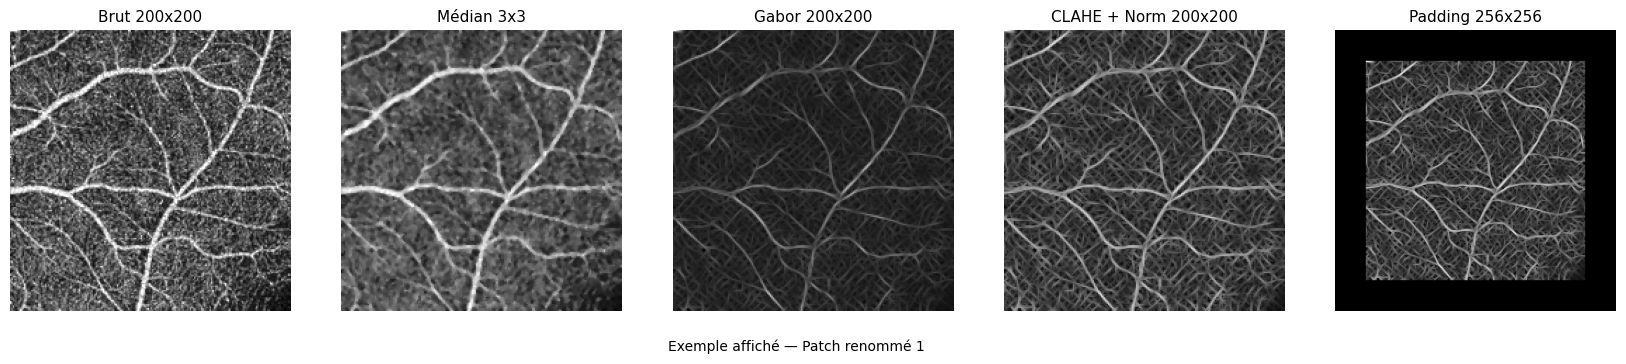

In [9]:
# Visualisation d'un patch à travers toutes les étapes
index = 0  # choisir un patch 0..1199

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), facecolor='white')

axes[0].imshow(raw_patches_200[index], cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Brut 200x200", color='black', fontsize=11)
axes[0].axis('off')

axes[1].imshow(median_patches_200[index], cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Médian 3x3", color='black', fontsize=11)
axes[1].axis('off')

axes[2].imshow(gabor_patches_200[index], cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Gabor 200x200", color='black', fontsize=11)
axes[2].axis('off')

axes[3].imshow(enhanced_patches_200[index], cmap='gray', vmin=0, vmax=255)
axes[3].set_title("CLAHE + Norm 200x200", color='black', fontsize=11)
axes[3].axis('off')

axes[4].imshow(padded_patches_256[index], cmap='gray', vmin=0, vmax=255)
axes[4].set_title("Padding 256x256", color='black', fontsize=11)
axes[4].axis('off')

renamed_id = int(renamed_ids[index])
fig.text(0.5, 0.02, f"Exemple affiché — Patch renommé {renamed_id}", ha='center', va='bottom', color='black', fontsize=10)
plt.subplots_adjust(left=0.03, right=0.99, top=0.92, bottom=0.14, wspace=0.08)
plt.show()


In [10]:
# Résumé des sorties disponibles
print("raw_patches_200 :", raw_patches_200.shape, raw_patches_200.dtype)
print("median_patches_200 :", median_patches_200.shape, median_patches_200.dtype)
print("gabor_patches_200 :", gabor_patches_200.shape, gabor_patches_200.dtype)
print("enhanced_patches_200 :", enhanced_patches_200.shape, enhanced_patches_200.dtype)
print("padded_patches_256 :", padded_patches_256.shape, padded_patches_256.dtype)
print("renamed_ids :", renamed_ids.shape, renamed_ids[:8], "...", renamed_ids[-8:])


raw_patches_200 : (1200, 200, 200) uint8
median_patches_200 : (1200, 200, 200) uint8
gabor_patches_200 : (1200, 200, 200) uint8
enhanced_patches_200 : (1200, 200, 200) uint8
padded_patches_256 : (1200, 256, 256) uint8
renamed_ids : (1200,) [1 2 3 4 5 6 7 8] ... [1193 1194 1195 1196 1197 1198 1199 1200]


SSIM brut -> médian     : 0.6403 ± 0.0385
SSIM médian -> gabor    : 0.5979 ± 0.0517
SSIM gabor -> clahe+norm: 0.7369 ± 0.0237
SSIM brut -> final      : 0.5743 ± 0.0324


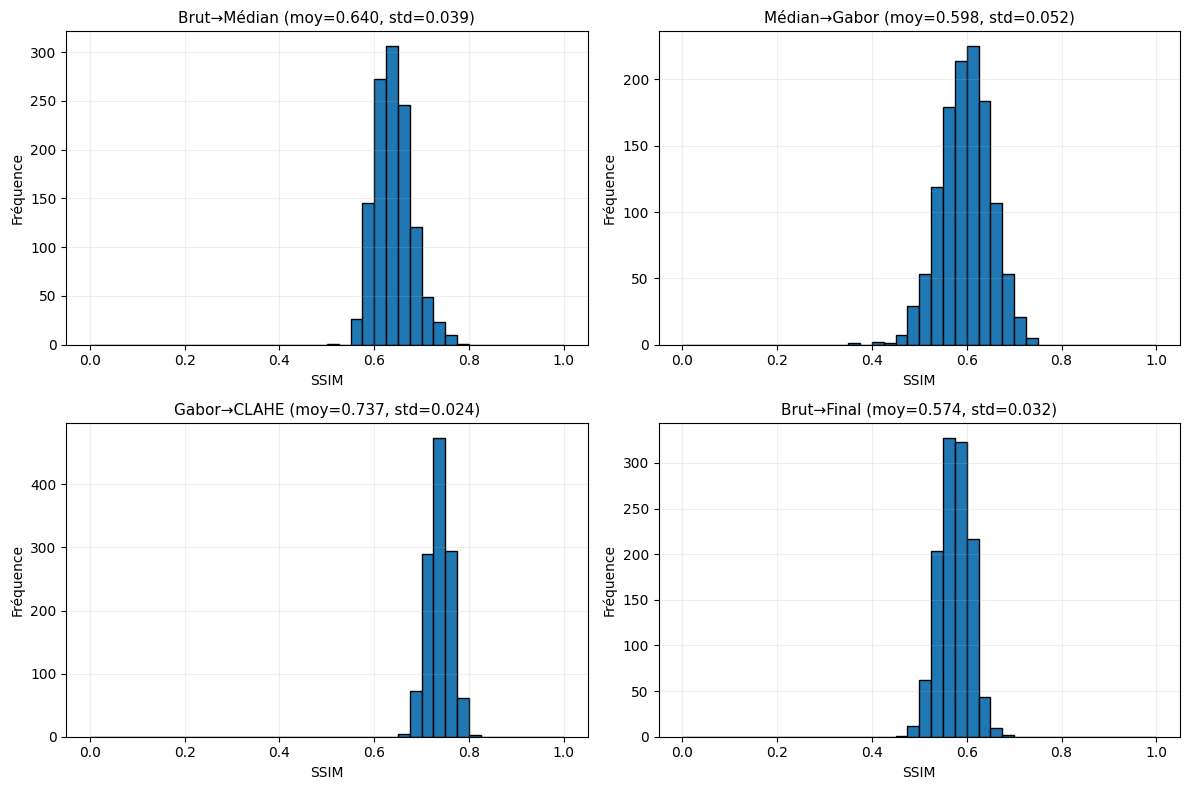

C:\Users\hp\AppData\Local\Temp\ipykernel_16020\3531104069.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(series, labels=labels, showmeans=True, meanline=True,


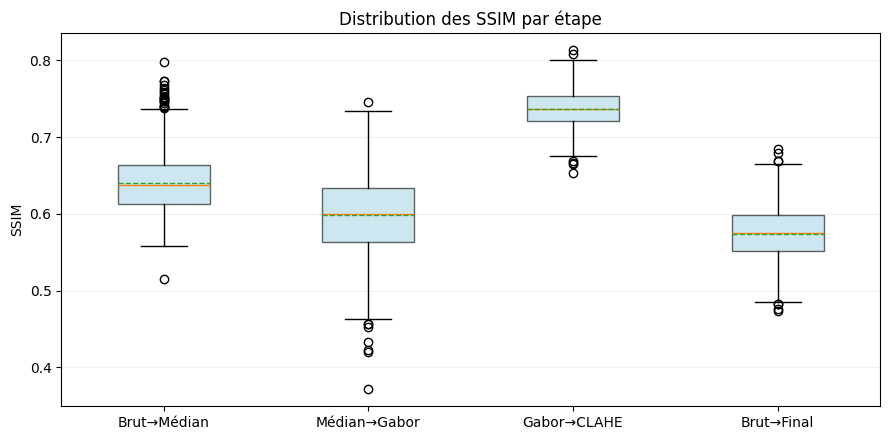

In [13]:
# Calcul du SSIM entre étapes du pipeline et affichage des distributions

from skimage.metrics import structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt

# Sécurisation des dtypes et bornes
def ensure_uint8(x):
    return x if (x.dtype == np.uint8) else x.astype(np.uint8)

A = ensure_uint8(raw_patches_200)          # brut 200×200
B = ensure_uint8(median_patches_200)       # médian 3×3 200×200
C = ensure_uint8(gabor_patches_200)        # Gabor 200×200
D = ensure_uint8(enhanced_patches_200)     # CLAHE + Norm 200×200

# Fonction utilitaire de calcul SSIM par patch
def ssim_per_patch(X, Y):
    scores = []
    for x, y in zip(X, Y):
        s, _ = ssim(x, y, data_range=255, full=True, gaussian_weights=True, sigma=1.5, use_sample_covariance=False)
        scores.append(s)
    return np.array(scores, dtype=np.float32)

# SSIM entre étapes consécutives
ssim_raw_med   = ssim_per_patch(A, B)   # brut -> médian
ssim_med_gab   = ssim_per_patch(B, C)   # médian -> gabor
ssim_gab_clahe = ssim_per_patch(C, D)   # gabor -> clahe+norm

# Optionnel: SSIM global brut -> final
ssim_raw_final = ssim_per_patch(A, D)

# Impression des moyennes (± écart-type)
def mean_std(arr):
    return float(np.nanmean(arr)), float(np.nanstd(arr))

m1, s1 = mean_std(ssim_raw_med)
m2, s2 = mean_std(ssim_med_gab)
m3, s3 = mean_std(ssim_gab_clahe)
m4, s4 = mean_std(ssim_raw_final)

print(f"SSIM brut -> médian     : {m1:.4f} ± {s1:.4f}")
print(f"SSIM médian -> gabor    : {m2:.4f} ± {s2:.4f}")
print(f"SSIM gabor -> clahe+norm: {m3:.4f} ± {s3:.4f}")
print(f"SSIM brut -> final      : {m4:.4f} ± {s4:.4f}")

# Affichages: histogrammes et boxplots
labels = ["Brut→Médian", "Médian→Gabor", "Gabor→CLAHE", "Brut→Final"]
series = [ssim_raw_med, ssim_med_gab, ssim_gab_clahe, ssim_raw_final]

# Histogrammes
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')
axes = axes.ravel()
bins = np.linspace(0, 1, 41)

for ax, data, lab, (m, s) in zip(axes, series, labels, [(m1,s1),(m2,s2),(m3,s3),(m4,s4)]):
    ax.hist(data, bins=bins, edgecolor='black')
    ax.set_title(f"{lab} (moy={m:.3f}, std={s:.3f})", color='black', fontsize=11)
    ax.set_xlabel("SSIM", color='black')
    ax.set_ylabel("Fréquence", color='black')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Boxplots comparatifs
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5), facecolor='white')
ax.boxplot(series, labels=labels, showmeans=True, meanline=True,
           patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.6))
ax.set_ylabel("SSIM", color='black')
ax.set_title("Distribution des SSIM par étape", color='black', fontsize=12)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


In [16]:
#.......... Sauvegarde des patches finaux 256x256 dans un dossier "Gabor_Patches"

import cv2
from pathlib import Path
from tqdm import tqdm

#.......... Dossier de sortie
OUTPUT_GABOR_DIR = Path(r"C:\Users\hp\OneDrive\Bureau\PRIM\PRIM-Project\Data\Gabor_Patches")
OUTPUT_GABOR_DIR.mkdir(parents=True, exist_ok=True)

print(f"Sauvegarde des {len(padded_patches_256)} patches finaux dans : {OUTPUT_GABOR_DIR}")

#.......... Boucle d’enregistrement
for i, patch in tqdm(enumerate(padded_patches_256, start=1),
                     total=len(padded_patches_256),
                     desc="Export Gabor patches",
                     ncols=80):

    #...... Conversion uint8 pour écriture propre
    patch_u8 = patch.astype(np.uint8)

    #...... Nom du fichier : 1.bmp, 2.bmp, ..., 1200.bmp
    out_path = OUTPUT_GABOR_DIR / f"{i}.bmp"

    #...... Sauvegarde
    ok = cv2.imwrite(str(out_path), patch_u8)
    if not ok:
        raise IOError(f"Échec d'écriture : {out_path}")

print("Terminé : tous les patches Gabor finalisés ont été sauvegardés.")


Sauvegarde des 1200 patches finaux dans : C:\Users\hp\OneDrive\Bureau\PRIM\PRIM-Project\Data\Gabor_Patches


Export Gabor patches: 100%|████████████████| 1200/1200 [00:11<00:00, 107.82it/s]

Terminé : tous les patches Gabor finalisés ont été sauvegardés.
